## Audio Filtering And Signal Enhancement

In [1]:
import numpy as np
import pandas as pd
import librosa
from nara_wpe.wpe import wpe
from nara_wpe.utils import stft, istft
import noisereduce as nr
import pyloudnorm as pyln
from pathlib import Path
from matplotlib import pyplot as plt
from src.dataset import sanitize
import IPython.display as ipd
from tqdm import tqdm
import soundfile as sf

SR=16000
TARGET_LUFS=-23.0
DATA_DIR = Path("data")
TORONTO = DATA_DIR / Path("toronto")
TORONTO_CLEAN = DATA_DIR / Path("toronto_clean")


In [ ]:
stft_options = dict(size=512, shift=128)

def dereverberate(y, taps=10, delay=3, iterations=3):
    y = y[np.newaxis, :].astype(np.float64)
    Y = stft(y, **stft_options).transpose(2, 0, 1)
    Z = wpe(Y, taps=taps, delay=delay, iterations=iterations)
    z = istft(Z.transpose(1, 2, 0), size=stft_options["size"], shift=stft_options["shift"])
    return z[0]

def enhance_audio(input, sr=SR, target_lufs=TARGET_LUFS):
  y, _ = librosa.load(input, sr=sr)
  y = dereverberate(y)
  y = nr.reduce_noise(y=y, sr=sr, stationary=False)

  meter = pyln.Meter(sr)
  loudness = meter.integrated_loudness(y)
  y = pyln.normalize.loudness(y, loudness, target_lufs)

  return y.astype(np.float32)


In [2]:
toronto_ids = set([f.name for f in TORONTO.glob("toronto_*")])

toronto_test_ids = set(['toronto_27', 'toronto_46', 'toronto_42', 'toronto_37', 'toronto_89', 'toronto_43',
'toronto_157', 'toronto_9', 'toronto_156', 'toronto_7', 'toronto_123', 'toronto_54', 'toronto_67',
'toronto_62', 'toronto_81', 'toronto_134', 'toronto_148', 'toronto_21', 'toronto_135', 'toronto_166',
'toronto_58'])

labels = pd.read_json(TORONTO / "labels.jsonl", lines=True)

toronto_df = []
for f in TORONTO.rglob("*.wav"):
    toronto_df.append({
        "filename": f.name,
        "path": str(f),
        "speaker_id": f.parent.name,
        "duration": librosa.get_duration(path=f),
        "label": labels[f"dataset/{f.parent.name}/{f.name}"][0]
    })

toronto_df = pd.DataFrame(toronto_df)
toronto_df = sanitize(toronto_df)
toronto_df["split"] = np.where(
  toronto_df["speaker_id"].isin(toronto_test_ids), "test", "train"
)
toronto_df.to_parquet(TORONTO / "toronto.parquet")


After filter: 12722 / 18198 rows


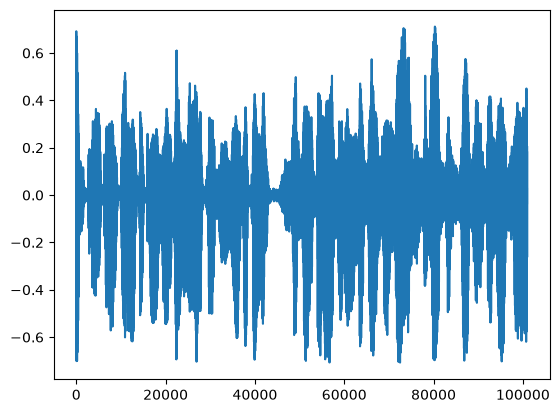

In [37]:
sample = toronto_df.iloc[1000]

plt.plot(librosa.load(sample["path"], sr=SR)[0])
plt.show()
ipd.Audio(sample["path"], rate=SR)


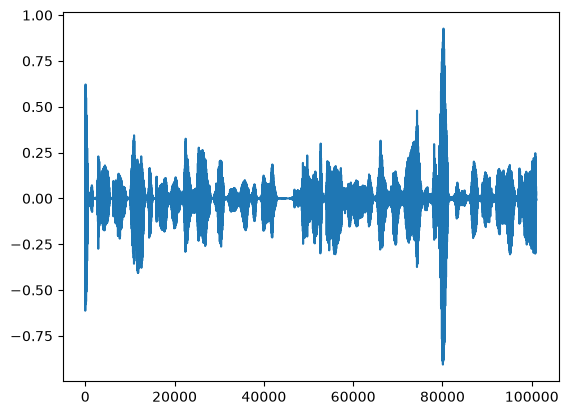

In [38]:
enhanced = enhance_audio(sample["path"])

plt.plot(enhanced)
plt.show()
ipd.Audio(enhanced, rate=SR)


In [ ]:
def build_clean_dataset(df, output_dir, sr=SR):
  output_dir = Path(output_dir)
  output_dir.mkdir(parents=True, exist_ok=True)

  rows = []
  failed = []

  for _, row in tqdm(df.iterrows(), total=len(df)):
    try:
      enhanced = enhance_audio(row.path)

      speaker_dir = output_dir / row.speaker_id
      speaker_dir.mkdir(parents=True, exist_ok=True)
      out_path = speaker_dir / row.filename
      sf.write(out_path, enhanced, sr)

      new_row = row.to_dict()
      new_row["path"] = str(out_path)
      new_row["duration"] = len(enhanced) / sr
      rows.append(new_row)
    except Exception as e:
        failed.append((row.filename, str(e)))

  if failed:
    print(f"Failed on {len(failed)} / {len(df)} files:")
    for name, err in failed[:10]:
      print(f"  {name}: {err}")

  clean_df = pd.DataFrame(rows)

  clean_df.to_parquet(output_dir / "toronto.parquet")
  return clean_df

toronto_df_clean = build_clean_dataset(toronto_df, TORONTO_CLEAN)


 17%|█▋        | 2174/12722 [03:59<21:38,  8.12it/s]/opt/miniforge3/envs/deep-audio/lib/python3.11/site-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
 21%|██        | 2609/12722 [04:48<18:54,  8.91it/s]/opt/miniforge3/envs/deep-audio/lib/python3.11/site-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
 38%|███▊      | 4891/12722 [08:55<12:19, 10.60it/s]/opt/miniforge3/envs/deep-audio/lib/python3.11/site-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
 52%|█████▏    | 6616/12722 [12:00<11:56,  8.52it/s]/opt/miniforge3/envs/deep-audio/lib/python3.11/site-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
 85%|████████▍ | 107

Failed on 2 / 12722 files:
  toronto_138_230.wav: Audio must have length greater than the block size.
  toronto_170_156.wav: Audio must have length greater than the block size.
